In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

order_items = pd.read_csv(r'D:/Datathon/data/order_items.csv', low_memory=False)
orders = pd.read_csv(r'D:/Datathon/data/orders.csv')
products = pd.read_csv(r'D:/Datathon/data/products.csv')
payments = pd.read_csv(r'D:/Datathon/data/payments.csv')

orders['order_date'] = pd.to_datetime(orders['order_date'])

In [13]:
df_items = order_items.merge(products[['product_id', 'cogs']], on='product_id', how='left')
df_full = df_items.merge(orders[['order_id', 'customer_id', 'order_date']], on='order_id', how='left')
df_full = df_full.merge(payments[['order_id', 'payment_value']], on='order_id')

df_full['revenue'] = df_full['unit_price'] * df_full['quantity'] - df_full['discount_amount']
df_full['cost'] = df_full['cogs'] * df_full['quantity']
df_full['profit'] = df_full['revenue'] - df_full['cost']
df_full['has_promo'] = df_full['promo_id'].notna().astype(int)

df_full.head()

,order_id,product_id,quantity,unit_price,discount_amount,promo_id,promo_id_2,cogs,customer_id,order_date,payment_value,revenue,cost,profit,has_promo
0,1,2400,7,1138.22,0.0,NaN,NaN,1053.798008,58578,2012-07-04,7967.54,7967.54,7376.586059,590.953941,0
1,2,609,7,10166.25,0.0,NaN,NaN,8987.704231,58621,2012-07-04,71163.75,71163.75,62913.929616,8249.820384,0
2,3,396,3,11220.33,0.0,NaN,NaN,10091.012256,58811,2012-07-04,33660.99,33660.99,30273.036767,3387.953233,0
3,4,635,5,10639.25,0.0,NaN,NaN,9205.430478,59453,2012-07-04,53196.25,53196.25,46027.152390,7169.097610,0
4,6,1935,1,1597.84,0.0,NaN,NaN,1048.696357,57821,2012-07-06,1597.84,1597.84,1048.696357,549.143643,0


In [ ]:
promo_summary = df_full.groupby('has_promo').agg({
    'payment_value': 'mean',   
    'order_id': 'nunique',
    'quantity': 'sum',
    'discount_amount': 'sum'
}).reset_index()

In [21]:
profit_summary = df_full.groupby('has_promo').agg({
    'profit': 'mean',   # AOV
    'revenue': 'mean',
}).reset_index()

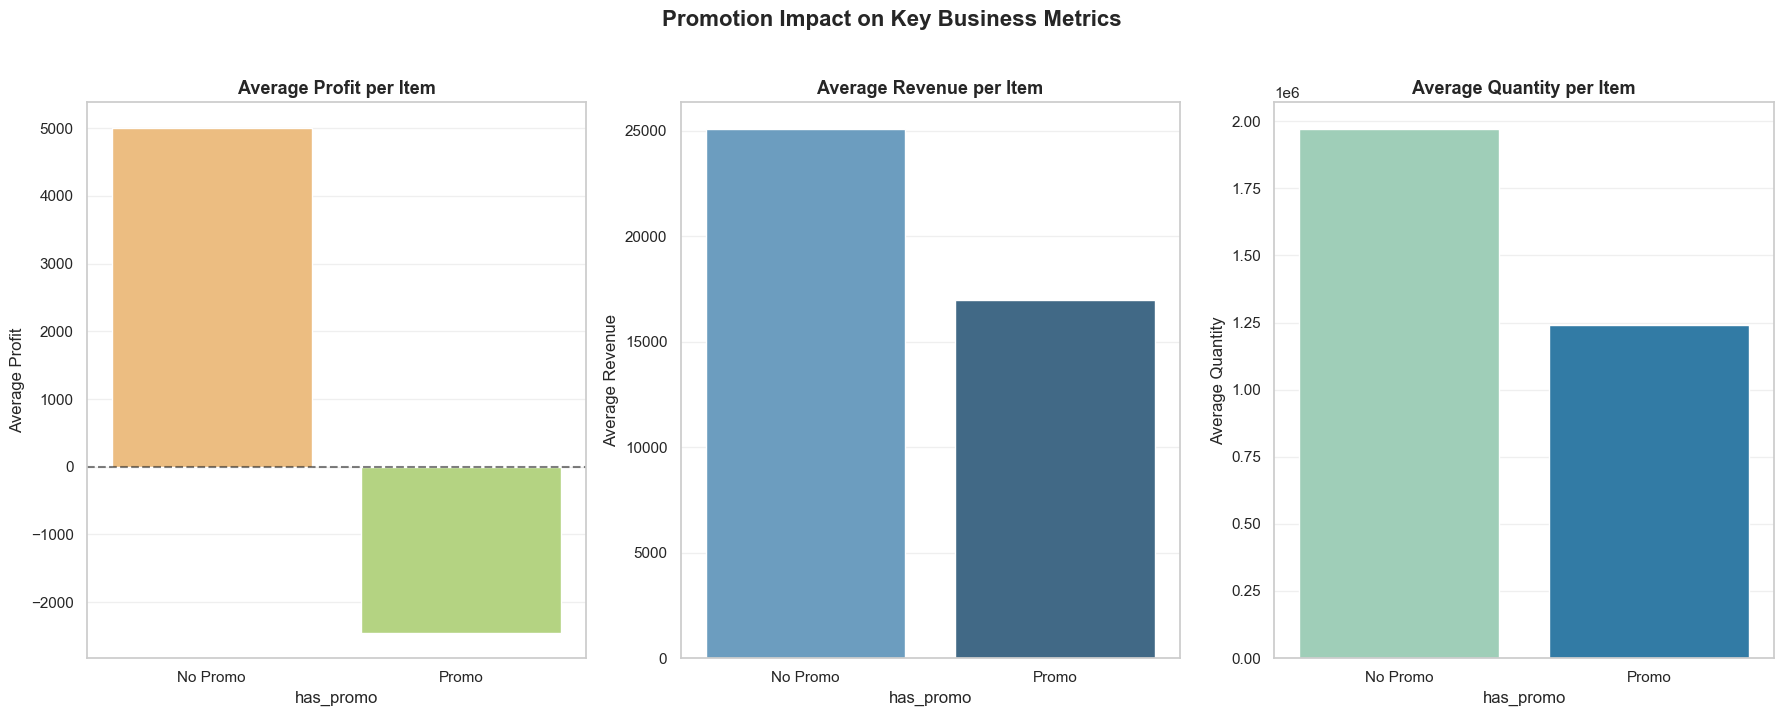

In [ ]:
plt.figure(figsize=(18, 7))

plt.subplot(1, 3, 1)
sns.barplot(
    data=profit_summary, 
    x='has_promo', 
    y='profit', 
    palette='RdYlGn', 
    hue='has_promo', 
    legend=False
)
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.title('Average Profit per Item', fontweight='bold', fontsize=13)
plt.xticks([0, 1], ['No Promo', 'Promo'])
plt.ylabel('Average Profit')
plt.grid(axis='y', alpha=0.3)

plt.subplot(1, 3, 2)
sns.barplot(
    data=profit_summary, 
    x='has_promo', 
    y='revenue', 
    palette='Blues_d', 
    hue='has_promo', 
    legend=False
)
plt.title('Average Revenue per Item', fontweight='bold', fontsize=13)
plt.xticks([0, 1], ['No Promo', 'Promo'])
plt.ylabel('Average Revenue')
plt.grid(axis='y', alpha=0.3)

plt.subplot(1, 3, 3)
sns.barplot(
    data=promo_summary, 
    x='has_promo', 
    y='quantity', 
    palette='YlGnBu', 
    hue='has_promo', 
    legend=False
)
plt.title('Average Quantity per Item', fontweight='bold', fontsize=13)
plt.xticks([0, 1], ['No Promo', 'Promo'])
plt.ylabel('Average Quantity')
plt.grid(axis='y', alpha=0.3)

plt.suptitle('Promotion Impact on Key Business Metrics', 
             fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()